In [2]:
import gc
import pandas as pd
import scanpy as sc
import numpy as np
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=150, color_map='viridis')
sc.logging.print_versions()

# Parameters
num_top_genes = 2000

from scipy.io import mmread
import anndata as ad

import matplotlib.pyplot as plt

## 今までで一番B同士が近かった方法で統合する ##

In [3]:
file_path = "/workspace/251011_data_integration/result/human_adata_167587x28871.h5ad"
adata_liver = sc.read_h5ad(file_path)

file_path = "/workspace/251011_data_integration/result/data6k_processed_5418x14343.h5ad"
adata_pbmc = sc.read_h5ad(file_path)

In [4]:
import anndata
import pandas as pd

# --- Step 1: 各AnnDataオブジェクトから指定した細胞集団を抽出 ---
# adata_liverから抽出したい細胞タイプのリスト
liver_celltypes_to_keep = ['Fibroblasts',
                           'B cells',
                           'Neutrophils',
                           'Cholangiocytes',
                           'Hepatocytes',
                           'Macrophages'
                           ]
liver_subset = adata_liver[adata_liver.obs['cell_type'].isin(liver_celltypes_to_keep), :]
liver_subset.obs = liver_subset.obs.rename(columns={'cell_type': 'celltype'})

# adata_pbmcから抽出したい細胞タイプのリスト
pbmc_celltypes_to_keep = ['Dendritic', 
                          'CD4Tcells', 
                          'NK', 
                          'CD8Tcells', 
                          'other', 
                          'Bcells', 
                          'Monocytes'
                          ]
pbmc_subset = adata_pbmc[adata_pbmc.obs['celltype'].isin(pbmc_celltypes_to_keep), :]


# --- Step 2: 抽出した2つのサブセットを1つに統合 ---

# 統合したいAnnDataオブジェクトを辞書にまとめる
adatas_to_merge = {
    'liver': liver_subset,
    'pbmc': pbmc_subset
}

# 余計な -liver, -pbmc が付くことを防ぐ
# obs の共通列を揃える
common_obs_cols = list(set.intersection(*[set(a.obs.columns) for a in adatas_to_merge.values()]))
for k in adatas_to_merge:
    adatas_to_merge[k].obs = adatas_to_merge[k].obs.loc[:, common_obs_cols]

In [5]:
# .concatenate() を使って統合
# batch_keyで細胞の由来（どのadataから来たか）を記録する
combined_adata = anndata.AnnData.concatenate(
    *adatas_to_merge.values(),
    batch_key='origin',  # 由来情報を示す新しい列名
    batch_categories=adatas_to_merge.keys(), # 各サンプルの名前
    join='outer'
)

/tmp/ipykernel_2870147/2803629089.py:3: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = anndata.AnnData.concatenate(


In [6]:
combined_adata

AnnData object with n_obs × n_vars = 33099 × 28895
    obs: 'pct_counts_ribo', 'log1p_total_counts_mt', 'leiden_res_0.50', 'pct_counts_in_top_50_genes', 'total_counts_ribo', 'pct_counts_in_top_500_genes', 'total_counts_hb', 'pct_counts_mt', 'n_genes', 'log1p_total_counts_ribo', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_100_genes', 'log1p_total_counts_hb', 'log1p_n_genes_by_counts', 'pct_counts_hb', 'celltype', 'total_counts', 'n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'origin'
    var: 'mt-liver', 'ribo-liver', 'hb-liver', 'n_cells_by_counts-liver', 'mean_counts-liver', 'log1p_mean_counts-liver', 'pct_dropout_by_counts-liver', 'total_counts-liver', 'log1p_total_counts-liver', 'n_cells-liver', 'highly_variable-liver', 'means-liver', 'dispersions-liver', 'dispersions_norm-liver', 'highly_variable_nbatches-liver', 'highly_variable_intersection-liver', 'mt-pbmc', 'ribo-pbmc', 'hb-pbmc', 'n_cells_by_counts-pbmc', 'mean_counts-pbmc', 'log1p_mean_counts-pbmc', 'pct_

In [7]:
# varの共通列を揃える
common_var_cols = list(set.intersection(*[set(a.var.columns) for a in adatas_to_merge.values()]))
for col in common_var_cols:
    combined_adata.var[col] = combined_adata.var[col+'-liver'].fillna(combined_adata.var[col+'-pbmc'])
    combined_adata.var.drop(columns=[col+'-liver', col+'-pbmc'], inplace=True)
# '-liver'で終わる列を.drop()で削除する
cols_to_drop = [col for col in combined_adata.var.columns if col.endswith('-liver')]
combined_adata.var.drop(columns=cols_to_drop, inplace=True)

/tmp/ipykernel_2870147/3053747133.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_adata.var[col] = combined_adata.var[col+'-liver'].fillna(combined_adata.var[col+'-pbmc'])
/tmp/ipykernel_2870147/3053747133.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_adata.var[col] = combined_adata.var[col+'-liver'].fillna(combined_adata.var[col+'-pbmc'])
/tmp/ipykernel_2870147/3053747133.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects

In [8]:
# 1. '-liver'で終わる列の名前をリストとして取得
cols_to_drop = [col for col in combined_adata.var.columns if col.endswith('-liver')]
# 2. 特定した列を.drop()で削除する
combined_adata.var.drop(columns=cols_to_drop, inplace=True)

In [9]:
combined_adata

AnnData object with n_obs × n_vars = 33099 × 28895
    obs: 'pct_counts_ribo', 'log1p_total_counts_mt', 'leiden_res_0.50', 'pct_counts_in_top_50_genes', 'total_counts_ribo', 'pct_counts_in_top_500_genes', 'total_counts_hb', 'pct_counts_mt', 'n_genes', 'log1p_total_counts_ribo', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_100_genes', 'log1p_total_counts_hb', 'log1p_n_genes_by_counts', 'pct_counts_hb', 'celltype', 'total_counts', 'n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'origin'
    var: 'n_cells_by_counts', 'hb', 'mean_counts', 'pct_dropout_by_counts', 'log1p_mean_counts', 'dispersions_norm', 'n_cells', 'means', 'ribo', 'total_counts', 'mt', 'dispersions', 'log1p_total_counts', 'highly_variable'
    obsm: 'X_pca', 'X_umap'

In [10]:
# 1. 変動遺伝子を選択 (batch_keyを指定するのがポイント)
sc.pp.highly_variable_genes(combined_adata, batch_key='origin')

# 2. (オプション) 変動遺伝子だけでデータをサブセット化
adata_pseudo = combined_adata[:, combined_adata.var.highly_variable]

# 3. データをスケール
sc.pp.scale(adata_pseudo, max_value=10)

# 4. PCAを実行
sc.pp.pca(adata_pseudo, n_comps=50)

# 5. 近傍グラフを計算
sc.pp.neighbors(adata_pseudo, n_pcs=30)

# 6. UMAPを計算
sc.tl.umap(adata_pseudo)

extracting highly variable genes
    finished (0:00:06)


/opt/250102_test_env/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/root/.pyenv/versions/3.11.4/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:04:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:21)
computing UMAP
    finished (0:03:17)


In [11]:
adata_pseudo.obs['celltype'] = adata_pseudo.obs['celltype'].replace({
    'Bcells': 'B cells'
})

/tmp/ipykernel_2870147/2059614423.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_pseudo.obs['celltype'] = adata_pseudo.obs['celltype'].replace({


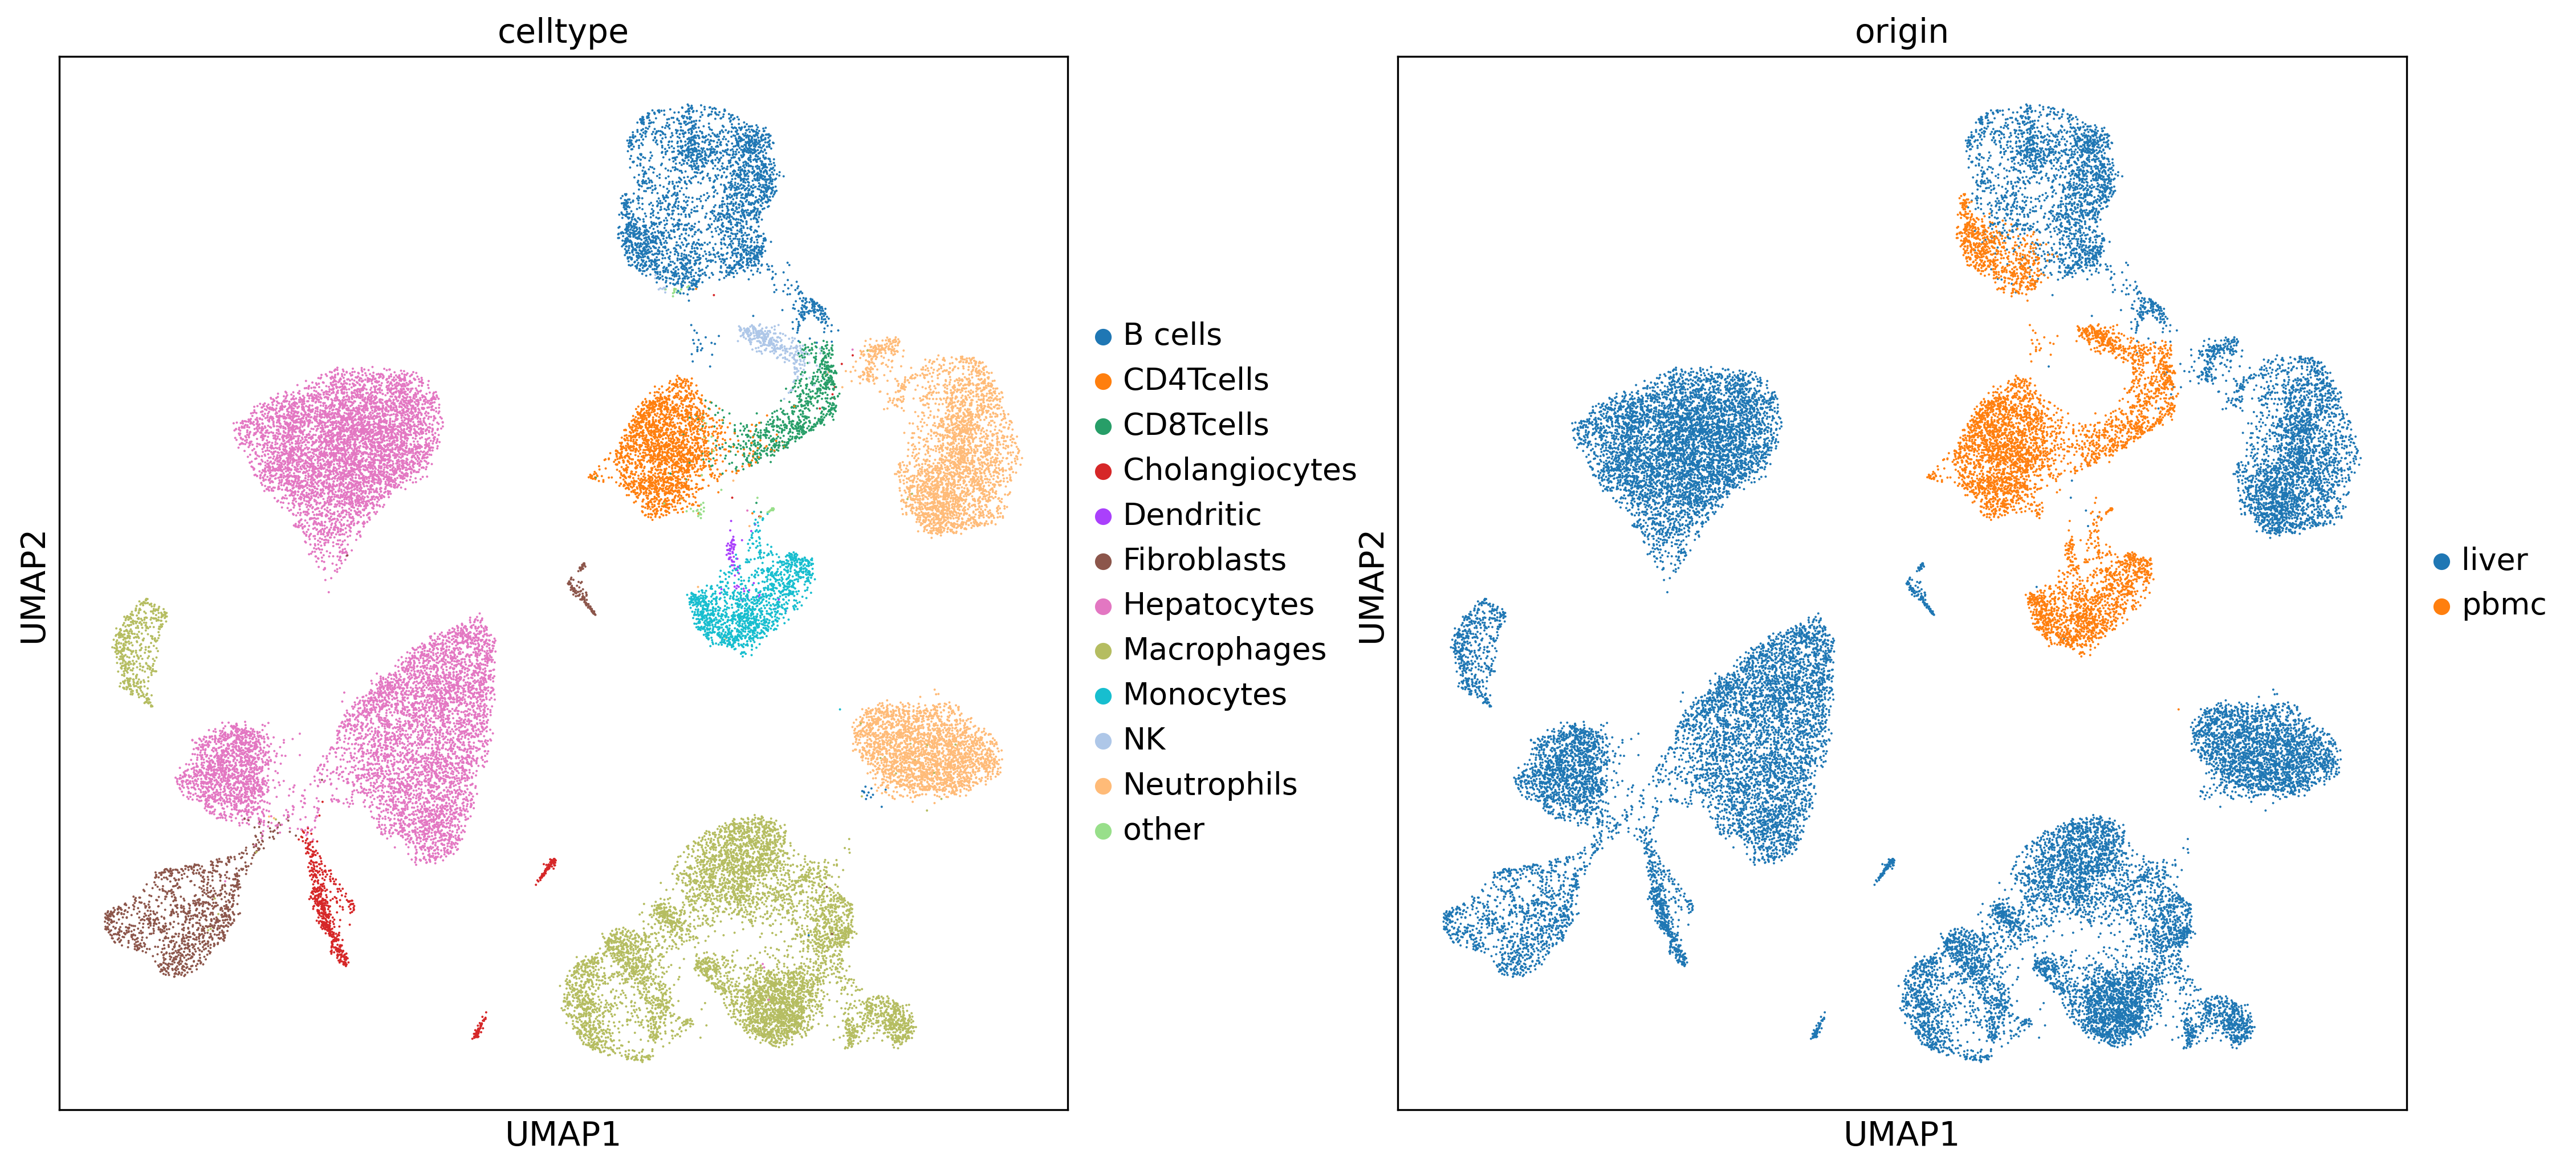

In [12]:
sc.pl.umap(adata_pseudo, color=['celltype', 'origin'], show=False)
plt.gcf().set_size_inches(18, 8)
plt.show()

## このデータに対してharmonyをかけてみる ##

In [13]:
adata_pseudo

AnnData object with n_obs × n_vars = 33099 × 2576
    obs: 'pct_counts_ribo', 'log1p_total_counts_mt', 'leiden_res_0.50', 'pct_counts_in_top_50_genes', 'total_counts_ribo', 'pct_counts_in_top_500_genes', 'total_counts_hb', 'pct_counts_mt', 'n_genes', 'log1p_total_counts_ribo', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_100_genes', 'log1p_total_counts_hb', 'log1p_n_genes_by_counts', 'pct_counts_hb', 'celltype', 'total_counts', 'n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'origin'
    var: 'n_cells_by_counts', 'hb', 'mean_counts', 'pct_dropout_by_counts', 'log1p_mean_counts', 'dispersions_norm', 'n_cells', 'means', 'ribo', 'total_counts', 'mt', 'dispersions', 'log1p_total_counts', 'highly_variable', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'celltype_colors', 'origin_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [14]:
import harmonypy as hm 
ho = hm.run_harmony(adata_pseudo.obsm['X_pca'], adata_pseudo.obs, vars_use=['origin'])
adata_pseudo.obsm['X_harmony'] = ho.Z_corr.T 

2025-11-20 16:33:03,507 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2025-11-20 16:33:07,818 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-20 16:33:08,308 - harmonypy - INFO - Iteration 1 of 10
2025-11-20 16:33:36,202 - harmonypy - INFO - Iteration 2 of 10
2025-11-20 16:34:05,608 - harmonypy - INFO - Iteration 3 of 10
2025-11-20 16:34:33,207 - harmonypy - INFO - Converged after 3 iterations


In [15]:
sc.pp.neighbors(adata_pseudo, use_rep='X_harmony', n_pcs=30)
sc.tl.umap(adata_pseudo)

computing neighbors
    finished (0:00:03)
computing UMAP
    finished (0:02:36)


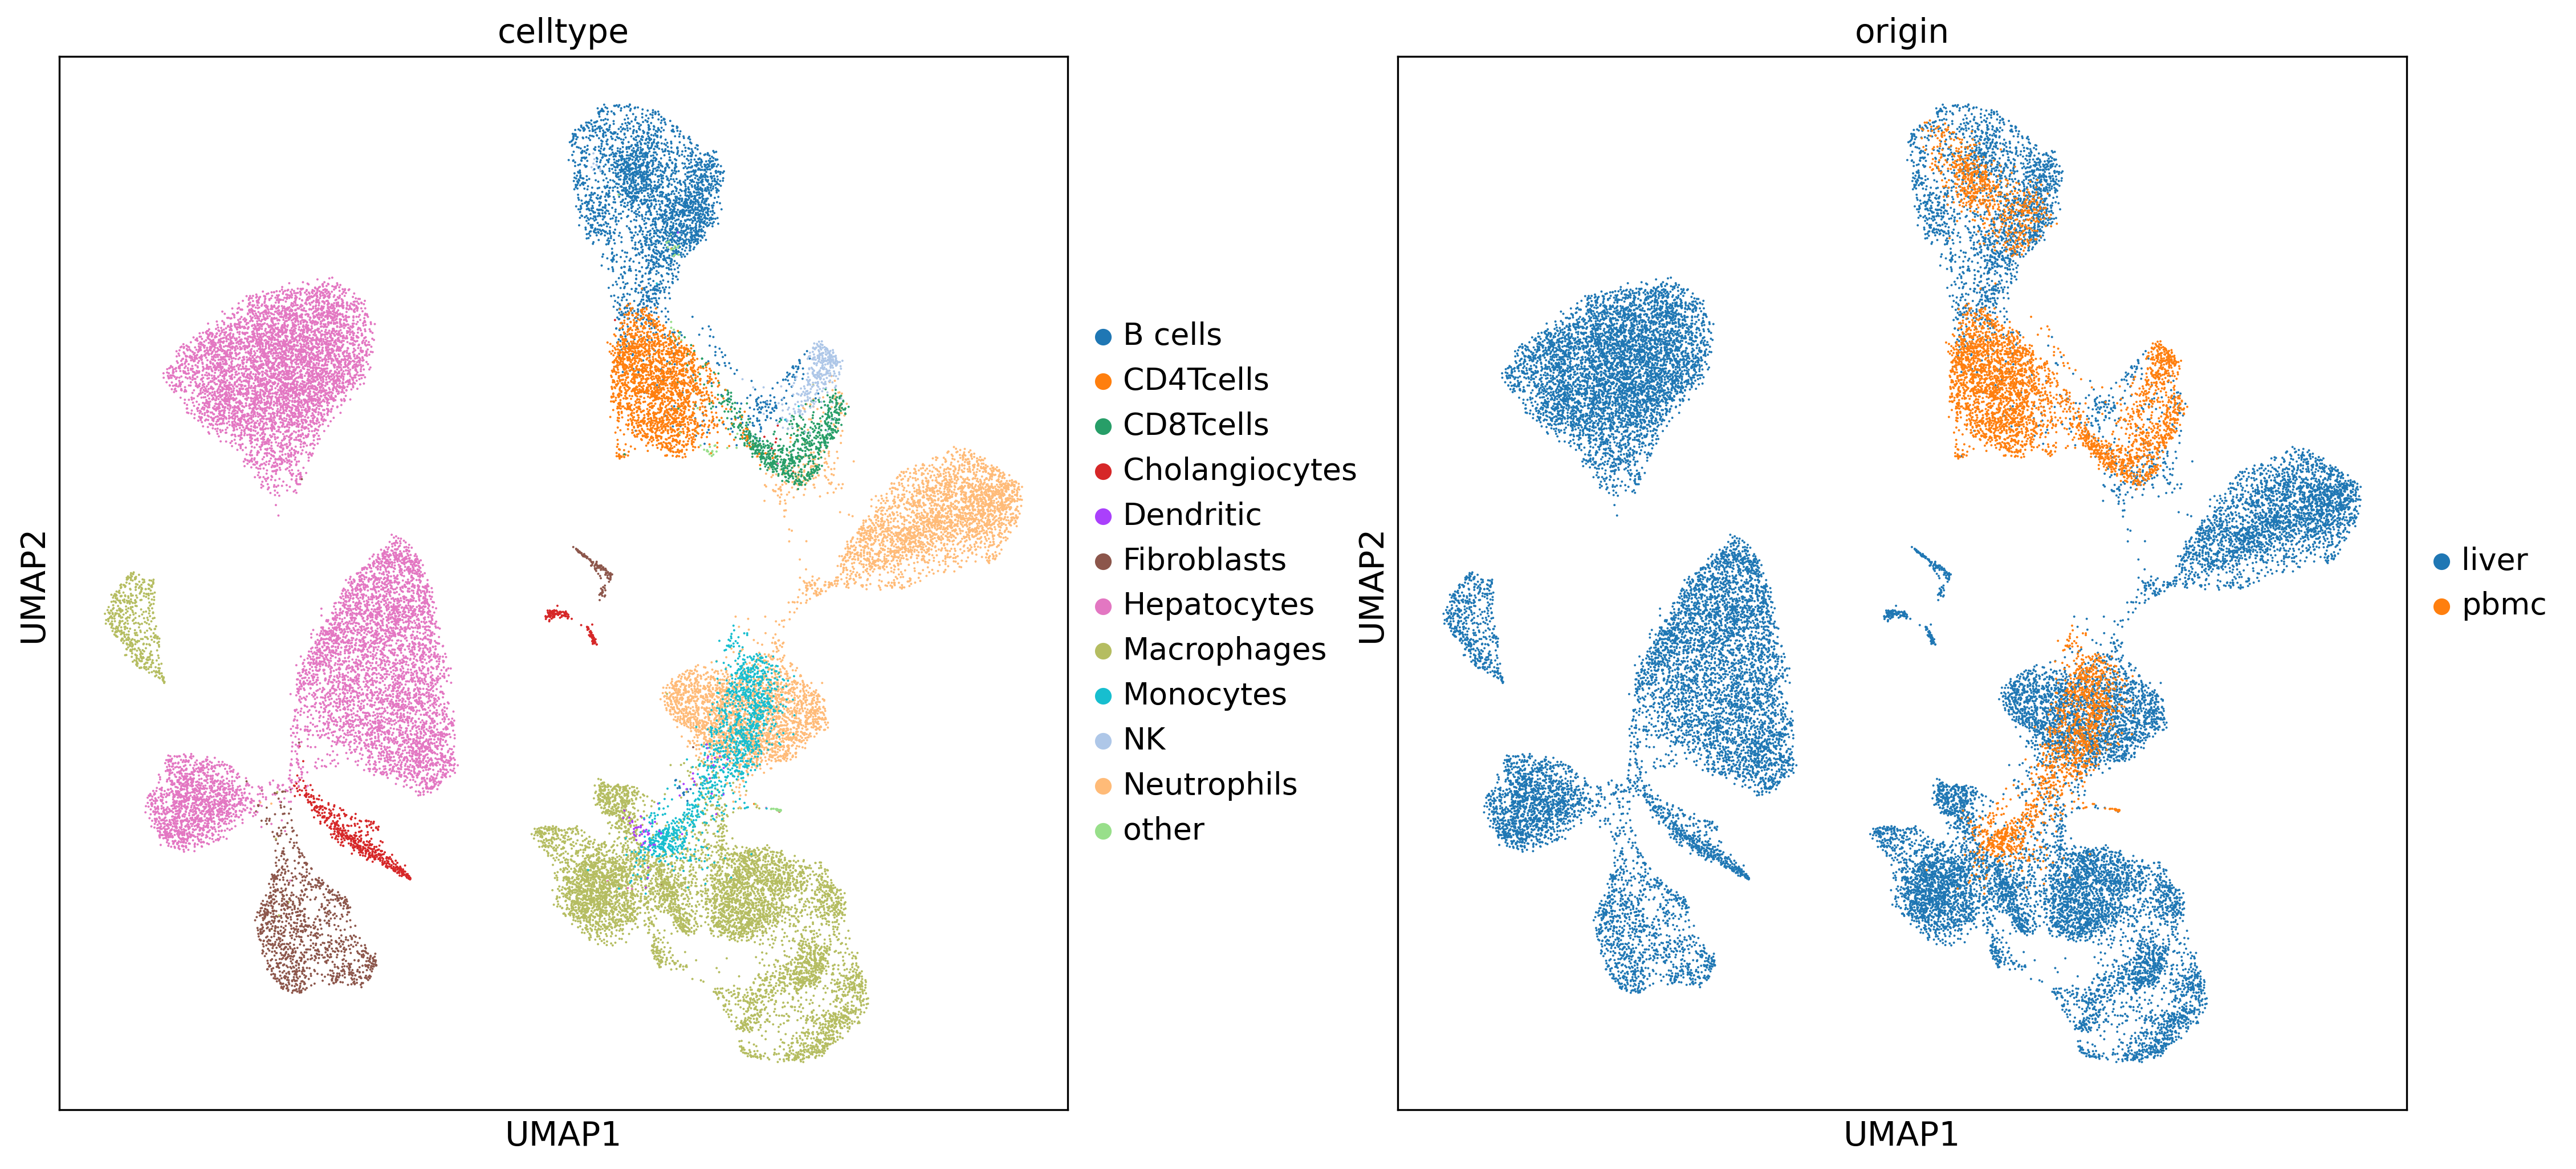

In [16]:
sc.pl.umap(adata_pseudo, color=['celltype', 'origin'], show=False)
plt.gcf().set_size_inches(18, 8)
plt.show()

多少の怪しさはあるものの、B細胞におけるバッチ補正はかなりきれいにワークしていそう

harmonyはあくまで低次元空間でのバッチ補正のため、統合した後に疑似バルクデータを作成するといったタスクをこなす場合には向いていない。